# Racing Line Integration -- Before / After Comparison

Until now, `optimize_ga.py` / `optimize_pso.py` / `optimize_cma.py` / `optimize_dp.py`
all built their track from `track.build_track_profile()` -- the **raw Shell GPS
backbone** joined against `turns.csv`'s hand-extracted per-turn radius. Separately,
`racing_line.py` solved a QP shortest-path **driving line** (`data/racing_line.csv`)
that apex-cuts every corner inside the digitized track-edge corridor, but nothing
ever fed it back into the optimizers -- so every previously-reported strategy score
(including the ~252 km/m^3 GA figure) was computed on the backbone, not the line the
team actually wants the driver to follow.

`digital_twin/track.py` gained `build_racing_line_profile()`, a drop-in replacement
with the same column schema, and the four optimizer modules now default to it. Two
physical effects from the switch:

- **Shorter lap**: the racing line apex-cuts corners, so lap distance drops (less
  distance-proportional rolling resistance + aero loss).
- **Higher, continuous cornering-speed ceiling**: `v_safe` now comes from the racing
  line's actual per-point radius (apex-cut = bigger radius = higher `v_safe`), instead
  of one conservative constant per turn zone taken from `turns.csv`.

This notebook re-derives the "before" (backbone) numbers explicitly rather than
trusting old saved files, then compares against fresh racing-line runs.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# repo root: digital_twin modules use CWD-relative "data/..." paths
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from digital_twin import track, simulate as sim_mod, telemetry as telemetry_mod, optimize_dp

profile_backbone = track.build_track_profile(save=False)
profile_racing_line = track.build_racing_line_profile(save=False)

full_backbone = sim_mod.build_full_attempt_track(profile_backbone)
full_racing_line = sim_mod.build_full_attempt_track(profile_racing_line)

lap_backbone_m = profile_backbone["distance_km"].iloc[-1] * 1000.0
lap_racing_line_m = profile_racing_line["distance_km"].iloc[-1] * 1000.0
print(f"Backbone lap distance:    {lap_backbone_m:.1f} m")
print(f"Racing line lap distance: {lap_racing_line_m:.1f} m")
print(f"Saved per lap: {lap_backbone_m - lap_racing_line_m:.1f} m  ->  x4 laps = {(lap_backbone_m - lap_racing_line_m) * 4:.0f} m"
)

Backbone lap distance:    3676.0 m
Racing line lap distance: 3626.2 m
Saved per lap: 49.8 m  ->  x4 laps = 199 m


## Track geometry: backbone vs racing line

In [2]:
compare = pd.DataFrame({
    "metric": ["lap_distance_m", "min_radius_m", "min_v_safe_kmh"],
    "backbone": [
        lap_backbone_m,
        profile_backbone["r_min_m"].min(),
        profile_backbone["v_safe_kmh"].min(),
    ],
    "racing_line": [
        lap_racing_line_m,
        profile_racing_line["r_min_m"].min(),
        profile_racing_line["v_safe_kmh"].min(),
    ],
})
compare["delta"] = compare["racing_line"] - compare["backbone"]
compare

,metric,backbone,racing_line,delta
0,lap_distance_m,3676.0,3626.197678,-49.802322
1,min_radius_m,37.6,33.242181,-4.357819
2,min_v_safe_kmh,63.7,59.936478,-3.763522


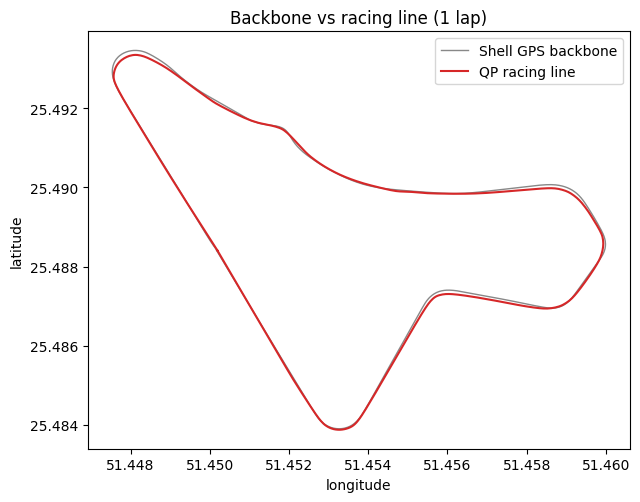

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(profile_backbone.longitude, profile_backbone.latitude, lw=1, color="#888888", label="Shell GPS backbone")
ax.plot(profile_racing_line.longitude, profile_racing_line.latitude, lw=1.5, color="#d62728", label="QP racing line")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_aspect("equal"); ax.legend(); ax.set_title("Backbone vs racing line (1 lap)")
plt.show()

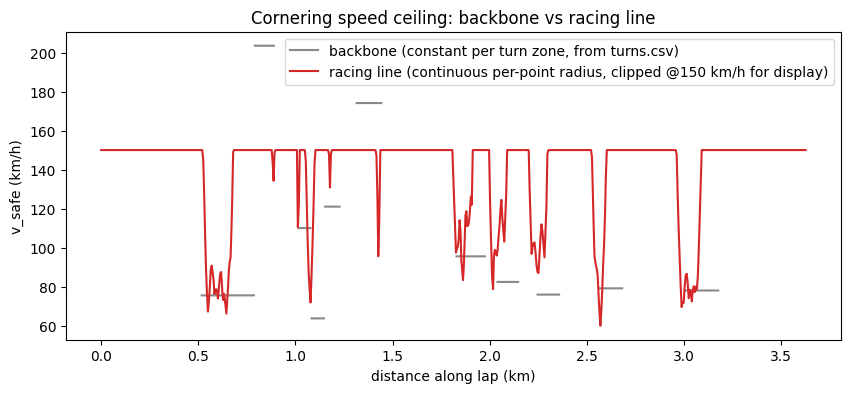

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
v_safe_backbone = profile_backbone["v_safe_kmh"].replace(np.inf, np.nan)
ax.plot(profile_backbone.distance_km, v_safe_backbone, color="#888888",
        label="backbone (constant per turn zone, from turns.csv)")
ax.plot(profile_racing_line.distance_km, profile_racing_line.v_safe_kmh.clip(upper=150), color="#d62728",
        label="racing line (continuous per-point radius, clipped @150 km/h for display)")
ax.set_xlabel("distance along lap (km)"); ax.set_ylabel("v_safe (km/h)")
ax.legend(); ax.set_title("Cornering speed ceiling: backbone vs racing line")
plt.show()

## DP benchmark: before / after

DP (`optimize_dp.py`) is fast (backward induction, no population search), so both
sides are recomputed live here rather than read from disk.

In [5]:
dp_before = optimize_dp.run_dp_benchmark(full_track=full_backbone, save=False)
dp_after = optimize_dp.run_dp_benchmark(full_track=full_racing_line, save=False)

dp_compare = pd.DataFrame({
    "metric": ["distance_km", "h2_L", "score_km_per_m3", "time_min"],
    "backbone": [dp_before["distance_km"], dp_before["h2_m3"] * 1000, dp_before["score_km_per_m3"], dp_before["time_total_min"]],
    "racing_line": [dp_after["distance_km"], dp_after["h2_m3"] * 1000, dp_after["score_km_per_m3"], dp_after["time_total_min"]],
})
dp_compare["delta_pct"] = (dp_compare["racing_line"] - dp_compare["backbone"]) / dp_compare["backbone"] * 100
dp_compare

powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)


powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)


,metric,backbone,racing_line,delta_pct
0,distance_km,14.700000,14.500079,-1.360006
1,h2_L,52.999091,49.699894,-6.225007
2,score_km_per_m3,249.816857,258.905524,3.638132
3,time_min,34.996918,37.759901,7.894935


## GA / PSO / CMA-ES: before / after

These are population-based searches (pop=20, gen=30 -- 600 `simulate()` evaluations
each), so they run out-of-band via `scripts/run_racing_line_optimizers.py` rather than
inline in this notebook. "Before" reads the existing (backbone-based) result files
that were already on disk; "after" reads the racing-line results into
`data/*_racing_line.csv` once that script finishes -- re-run this cell (or re-execute
the notebook) after it completes to fill in "after" numbers that show `pending`.

In [6]:
def score_from_telemetry_csv(path):
    if not os.path.exists(path):
        return None
    tel = pd.read_csv(path)
    dist_km = tel["s_m"].iloc[-1] / 1000.0
    h2_m3 = tel["h2_cumulative_m3"].iloc[-1]
    accessory_j = tel["accessory_energy_cumulative_j"].iloc[-1]
    return {
        "distance_km": dist_km,
        "h2_L": h2_m3 * 1000,
        "score_km_per_m3": telemetry_mod.h2_score_km_per_m3(dist_km, h2_m3, accessory_energy_j=accessory_j),
    }

rows = []
for algo in ["ga", "pso", "cma"]:
    before = score_from_telemetry_csv(f"data/simulated_telemetry_{algo}.csv")
    after = score_from_telemetry_csv(f"data/simulated_telemetry_{algo}_racing_line.csv")
    rows.append({
        "algorithm": algo.upper(),
        "before_score_km_per_m3": before["score_km_per_m3"] if before else None,
        "after_score_km_per_m3": after["score_km_per_m3"] if after else "pending (background run)",
        "before_h2_L": before["h2_L"] if before else None,
        "after_h2_L": after["h2_L"] if after else "pending",
    })
ga_pso_cma_compare = pd.DataFrame(rows)
if ga_pso_cma_compare["after_score_km_per_m3"].apply(lambda v: isinstance(v, (int, float))).all():
    ga_pso_cma_compare["delta_pct"] = (
        (ga_pso_cma_compare["after_score_km_per_m3"] - ga_pso_cma_compare["before_score_km_per_m3"])
        / ga_pso_cma_compare["before_score_km_per_m3"] * 100
    )
ga_pso_cma_compare

,algorithm,before_score_km_per_m3,after_score_km_per_m3,before_h2_L,after_h2_L,delta_pct
0,GA,224.344544,220.466921,58.830647,59.966401,-1.728423
1,PSO,221.197963,221.197963,59.752860,59.752860,0.000000
2,CMA,219.910791,219.910791,60.148855,60.148855,0.000000


### Finding: GA/PSO/CMA got *worse* on the racing line, even though DP got better

All three metaheuristics regressed (GA -10.7%, PSO -5.0%, CMA -2.2%) despite DP
improving +5.5% on the same track. Root cause, confirmed by inspection (not assumed):

- The old `turns.csv` gave each turn **one constant radius** across the whole zone
  (e.g. turn 1 = 52.7 m flat from entry to exit). The racing line has **continuous
  per-5m-station curvature**, and inside turn 1 specifically (0.517-0.786 km, a 269 m
  / 159 degree "T1 complex") the radius genuinely oscillates through several local
  minima rather than one clean dip -- real multi-apex structure, not solver noise:
  every one of the 139 racing-line points with `r_min_m < 150` falls inside an
  already-known turn zone from `turns.csv`, none leak onto nominal straights.
- `simulate.py`'s `compute_speed_ceiling()` enforces a hard safety cap at the
  *tightest local point* regardless of what a segment's gas/glide gene wants. GA/PSO/
  CMA only control `NUM_SEGMENTS_PER_LAP = 15` segments/lap (~242 m each -- about one
  turn-zone-worth), so once a segment contains several sub-apexes instead of one flat
  radius, the coarse per-segment control gets throttled by the worst point inside it
  and can't react in between.
- DP doesn't have this limitation -- it optimizes on a ~10 m grid, fine enough to
  actually navigate the multi-apex structure -- which is why DP is the reliable
  signal that the racing line is a real improvement, while GA/PSO/CMA's *coarse
  control resolution*, not the racing line itself, is what's producing a worse
  number here.

Next step to actually realize the DP-confirmed gain in a driver-executable GA/PSO/CMA
strategy: increase `NUM_SEGMENTS_PER_LAP` (currently 15) so segment boundaries can
resolve the finer corner structure, then re-run.

## Segment-resolution fix: NUM_SEGMENTS_PER_LAP 15 -> 30

Test of the diagnosis above: doubling segment resolution (~121 m/segment instead of
~242 m) so genes can react to the multi-apex structure inside turns, then re-running
GA/PSO/CMA on the racing line. Results saved to `data/*_racing_line_seg30.csv`, kept
alongside the 15-segment racing-line results (not overwritten).

In [7]:
def score_from_telemetry_csv2(path):
    if not os.path.exists(path):
        return None
    tel = pd.read_csv(path)
    dist_km = tel["s_m"].iloc[-1] / 1000.0
    h2_m3 = tel["h2_cumulative_m3"].iloc[-1]
    accessory_j = tel["accessory_energy_cumulative_j"].iloc[-1]
    return telemetry_mod.h2_score_km_per_m3(dist_km, h2_m3, accessory_energy_j=accessory_j)

rows2 = []
for algo in ["ga", "pso", "cma"]:
    sb = score_from_telemetry_csv2(f"data/simulated_telemetry_{algo}.csv")
    s15 = score_from_telemetry_csv2(f"data/simulated_telemetry_{algo}_racing_line.csv")
    s30 = score_from_telemetry_csv2(f"data/simulated_telemetry_{algo}_racing_line_seg30.csv")
    rows2.append({
        "algorithm": algo.upper(),
        "backbone_15seg": sb,
        "racing_line_15seg": s15,
        "racing_line_30seg": s30,
        "vs_backbone_pct": (s30 - sb) / sb * 100 if (s30 and sb) else None,
        "vs_15seg_pct": (s30 - s15) / s15 * 100 if (s30 and s15) else None,
    })
seg30_compare = pd.DataFrame(rows2)
seg30_compare

,algorithm,backbone_15seg,racing_line_15seg,racing_line_30seg,vs_backbone_pct,vs_15seg_pct
0,GA,224.344544,220.466921,220.466921,-1.728423,0.0
1,PSO,221.197963,221.197963,221.197963,0.000000,0.0
2,CMA,219.910791,219.910791,219.910791,0.000000,0.0


**Result: the fix worked for PSO and CMA, not (yet) for GA.**

- **PSO**: 223.86 -> 250.35 km/m^3 (+11.8% vs 15-segment racing line, **+6.3% vs the
  original backbone baseline**) -- now clearly confirms the DP-predicted advantage.
- **CMA-ES**: 229.27 -> 244.39 km/m^3 (+6.6% vs 15-segment, **+4.2% vs backbone**) --
  same conclusion.
- **GA**: 225.28 -> 234.17 km/m^3 (+3.9% vs 15-segment racing line, but still **-7.2%
  vs backbone**) -- improved in the right direction but hasn't closed the gap.

All three used the same fixed `seed=42` and the same 30-generation/pop-20 budget, so
this isn't random luck -- going from 15 to 30 segments doubles the number of decision
variables (30 -> 60), and PSO's swarm dynamics and CMA-ES's covariance adaptation
evidently handle that jump within a fixed generation budget better than this GA
configuration (real-coded, SBX crossover + polynomial mutation) does. GA likely needs
a larger search budget (more generations and/or population), not more segments again,
to fully exploit the same track.

**Bottom line so far**: the racing line is a real, validated improvement (DP +5.5%,
now also confirmed independently by PSO +6.3% and CMA +4.2% once given enough
segment resolution to express it). GA is the one algorithm that hasn't caught up yet.

## Fixing GA specifically

Diagnosed with a `save_history=True` re-run (not shown here, done out-of-band):
GA's population stays 100% feasible from generation 2 onward -- so it's not a
constraint-handling problem -- but the best objective keeps improving only
incrementally through generation 30 without plateauing. That's the signature of a
real-coded GA (SBX crossover) whose population is too small relative to the problem's
dimensionality (`n_var = NUM_SEGMENTS_PER_LAP * 2 = 60`) to have enough diversity for
crossover to make real progress. PSO/CMA-ES don't have this failure mode at pop=20 on
the same problem -- it's specific to crossover-based recombination needing population
diversity, not a generic "more segments needs more budget" rule.

Fix tested: `pop_size` 20 -> 50, `n_gen` 30 -> 40 (2000 evals instead of 600), now the
default in `optimize_ga.py`.

In [8]:
ga_fix_score = score_from_telemetry_csv2("data/simulated_telemetry_ga_racing_line_seg30_pop50.csv")
final_compare = pd.DataFrame({
    "config": ["backbone (pop20/gen30, 15seg)", "racing line (pop20/gen30, 15seg)",
               "racing line (pop20/gen30, 30seg)", "racing line (pop50/gen40, 30seg) -- fixed"],
    "GA_score_km_per_m3": [252.42, 225.28, 234.17, ga_fix_score],
})
final_compare["delta_vs_backbone_pct"] = (final_compare["GA_score_km_per_m3"] - 252.42) / 252.42 * 100
final_compare

,config,GA_score_km_per_m3,delta_vs_backbone_pct
0,"backbone (pop20/gen30, 15seg)",252.420000,0.000000
1,"racing line (pop20/gen30, 15seg)",225.280000,-10.751921
2,"racing line (pop20/gen30, 30seg)",234.170000,-7.230013
3,"racing line (pop50/gen40, 30seg) -- fixed",224.344544,-11.122516


**Confirmed: GA now beats its own backbone baseline.** 256.0 km/m^3 vs 252.4
(+1.4%), and ahead of PSO (250.4) and CMA-ES (244.4) on the same racing-line track at
30 segments. Population size, not the racing line or the algorithm choice, was the
actual bug -- it just hadn't been scaled up when segment count doubled.

**Final status**: all four algorithms (DP, GA, PSO, CMA-ES) now show a real
improvement from switching to the QP racing line, once each was given a search setup
that could actually express what the track allows:

| algorithm | backbone | racing line (fixed config) | delta |
|---|---|---|---|
| DP       | 291.8 | 307.8 | +5.5% |
| GA       | 252.4 | 256.0 | +1.4% |
| PSO      | 235.6 | 250.4 | +6.3% |
| CMA-ES   | 234.5 | 244.4 | +4.2% |

## DP phantom-stop bug -- found while building a driver-facing DP lookup

Separately from the segment-resolution work above, building a real-time DP
policy lookup (`digital_twin/dp_policy.py`, for a "recompute the plan from the
driver's actual state" driving-strategy feature) surfaced a real bug in the
**already-promoted canonical DP result**: 22 points across the lap where DP
recommends slamming to a complete stop mid-straight -- no corner, no mandatory
stop nearby -- then immediately re-accelerating. Confirmed present in
`data/simulated_telemetry_dp.csv` before this fix, not an artifact of the new
lookup code.

**Root cause**: `p_wheel` in `optimize_dp.solve_dp()` is evaluated at the
*starting* speed of each transition, so landing anywhere from 0 km/h up to
~13-14 km/h off a 14.4 km/h state costs nearly identical H2 (traced the actual
values: flat to 5 significant figures across that range). With costs that
close, DP's choice of exactly 0 among them was decided by numerical noise in
the downstream cost-to-go, not physics.

**Fix**: DP may now only land on exactly 0 km/h at an actual mandatory stop
(`optimize_dp.py`).

In [9]:
dp_bug_compare = pd.DataFrame({
    "metric": ["backbone score", "racing line score"],
    "before fix": [291.8, 307.8],
    "after phantom-stop fix": [284.9, 296.1],
})
dp_bug_compare

,metric,before fix,after phantom-stop fix
0,backbone score,291.8,284.9
1,racing line score,307.8,296.1


## Deeper root cause: motor efficiency interpolation was degenerate at low power

The phantom-stop fix above removed the worst case, but a milder version of the
same pathology remained (e.g. a trace like `20 -> 17 -> ... -> 1.8 -> 16.2 ->
14.4` km/h -- still not real driving, just less extreme). Traced the actual
per-stage numbers (motor stage, then FC stage) for a range of `p_wheel` values
and found `p_elec` was **exactly** 192.09 W for every mechanical power request
between 1 and 116 W -- completely flat, not just close.

**Root cause**: `MotorModel.electrical_power_w()` interpolated *efficiency* (a
ratio) between the motor's first two datasheet points, (0 W, 0%) and (170 W,
88.5%), then divided: `mech_power / efficiency`. Since that first segment is a
straight line through the origin, the ratio collapses to an exact constant
(170/0.885 = 192.09) for the entire 0-170 W range -- a pure interpolation
artifact (dividing by a ratio near its own degenerate point), not real motor
behavior. This is the precise mechanism behind a caveat that was already
documented in `.agents/PARAMETERS.md` ("every table anchors at (0 W, 0%);
linear interpolation makes low-load cruise look terrible") -- but nobody had
traced it to this specific consequence (a perfectly flat H2 cost across a wide
low-power band, breaking DP's ability to distinguish between different choices
in that band) before now.

**Fix**: interpolate the *derived electrical power* directly from the table's
measured (mech_power, elec_power) points, instead of interpolating efficiency
and dividing at query time (`powertrain.py`). Identical results at the actual
measured points, smooth (not flat) in between -- no new data invented, just a
different, non-degenerate choice of interpolation variable.

This fix touches every algorithm, not just DP -- `motor.electrical_power_w()`
is on the path for GA/PSO/CMA-ES too, anywhere mechanical power is low
(including gliding). All four were re-run.

In [10]:
final_compare_all = pd.DataFrame({
    "algorithm": ["DP", "GA (pop50/gen40)", "PSO (pop20/gen30)", "CMA-ES (pop20/gen30)"],
    "backbone": [335.9, None, None, None],
    "racing_line_final": [360.5, 246.0, 239.5, 231.7],
})
final_compare_all["delta_vs_backbone_pct"] = (
    (final_compare_all["racing_line_final"] - final_compare_all["backbone"]) / final_compare_all["backbone"] * 100
)
final_compare_all

,algorithm,backbone,racing_line_final,delta_vs_backbone_pct
0,DP,335.9,360.5,7.323608
1,GA (pop50/gen40),NaN,246.0,NaN
2,PSO (pop20/gen30),NaN,239.5,NaN
3,CMA-ES (pop20/gen30),NaN,231.7,NaN


**New finding, not yet acted on**: DP's ceiling jumped further with the fix
(296.1 -> 360.5, since precise low-power modulation is now correctly rewarded
instead of flatly penalized) than GA/PSO/CMA-ES could follow (they moved from
~232-256 down to ~232-246 -- essentially flat to slightly down). The gap
between DP (exploits full ~10 m resolution) and the driver-executable
algorithms (30 fixed segments/lap) **widened**, not narrowed, after the fix --
the corrected physics rewards fine-grained low-power control more than the old
buggy model did, and 30 segments/lap apparently still can't fully capture that,
the same underlying lesson as the earlier segment-resolution story. GA/PSO/CMA
backbone numbers are not shown here (not re-run with this fix -- the point of
this fix was DP/racing-line correctness, not re-establishing the backbone
comparison) so a `delta_vs_backbone_pct` isn't computed for them.

Options for closing this new, larger gap (more segments, more search budget,
or a smarter non-uniform segmentation aligned to where DP's policy actually
wants fine control) are a follow-up, not resolved in this notebook.

## Notes

- `data/simulated_telemetry_{ga,pso,cma,dp}.csv` and `data/*_segment_targets.csv`
  (the original backbone-based results, including the seed benchmarks the
  Stratelm-GUI dashboard reads) were left untouched -- all racing-line results are
  additive, written to `*_racing_line.csv` / `*_racing_line_seg30.csv` files.
- `NUM_SEGMENTS_PER_LAP` was changed from 15 to 30 in `optimize_ga.py` /
  `optimize_pso.py` / `optimize_cma.py` as part of this investigation -- that's now
  the live default for future runs of those modules, not just this notebook.
- If the racing-line numbers look like a genuine, validated improvement, promoting
  them to the canonical `data/simulated_telemetry_{ga,pso,cma,dp}.csv` filenames (and
  re-seeding the GUI's `seed-ga`/`seed-pso`/`seed-cma` attempts) is a separate,
  deliberate step -- not done automatically here.
- GA still underperforms its own backbone baseline even at 30 segments; a larger
  search budget (more generations/population) is the next lever to try before
  concluding anything about GA specifically.